In [1]:
# imports
import pandas as pd
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset loading 

The dataset is a folder of parquet files. Each instance is a single time series from a real well, a simulation or a hand-drawn case. 

The folder name is the event class (0 = normal, 1-9 = faults), while the file name tells whether it is a real well, a simulated or a drawn instance. 

In this part I read every file, add metadata fields (instance_id, event_class, source and well_id), and concatenate everything into a single dataframe. Since it's pretty big I reduce the float64 columns in float32 and save the result in a final Parquet file.

## 1.1 Dataset configuration (`dataset.ini`)

**Columns of each parquet file.** Every file has a `timestamp`, 27 sensor/state variables, and two labels:

| Group | Columns | Unit |
|---|---|---|
| Choke openings | `ABER-CKGL`, `ABER-CKP` | % |
| Valve states | `ESTADO-DHSV`, `-M1`, `-M2`, `-PXO`, `-SDV-GL`, `-SDV-P`, `-W1`, `-W2`, `-XO` | 0, 0.5 or 1 |
| Pressures | `P-ANULAR`, `P-JUS-BS`, `P-JUS-CKGL`, `P-JUS-CKP`, `P-MON-CKGL`, `P-MON-CKP`, `P-MON-SDV-P`, `P-PDG`, `PT-P`, `P-TPT` | Pa |
| Flow rates | `QBS`, `QGL` | m3/s |
| Temperatures | `T-JUS-CKP`, `T-MON-CKP`, `T-PDG`, `T-TPT` | °C |
| Labels | `class` (label of the observation), `state` (well operational status) | - |

`MON` and `JUS` mean upstream and downstream of a component, and `ESTADO` means state.


**Event classes.** Each event type has a numeric label, which is also the name of the folder where its instances are stored:

| Class | Event | Transient |
|---|---|---|
| 0 | Normal operation | - |
| 1 | Abrupt increase of BSW | yes |
| 2 | Spurious closure of DHSV | yes |
| 3 | Severe slugging | no |
| 4 | Flow instability | no |
| 5 | Rapid productivity loss | yes |
| 6 | Quick restriction in PCK | yes |
| 7 | Scaling in PCK | yes |
| 8 | Hydrate in production line | yes |
| 9 | Hydrate in service line | yes |


**Labels in `class`.** The folder gives one event class to the whole instance (`event_class`), while the column `class` labels each row.
In a fault instance it goes through three phases: 
- 0 (normal operation)
- 101-109 (transient, when the fault is starting)
- 1-9 (stable fault).

In this project, "anomaly" means any class from 1 to 9.

In [2]:
DIR = Path("dataset")
files = sorted(DIR.rglob("*.parquet"))
print(len(files), "files")

2228 files


In [3]:
def load_instance(path: Path) -> pd.DataFrame:
    """Read each instance of Parquet file to add metadata"""
    df = pd.read_parquet(path)

    if isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()

    for c in df.select_dtypes("float64").columns:
            df[c] = df[c].where(df[c].abs() <= np.finfo("float32").max).astype("float32")

    # Adding metadata
    file_name = path.stem.upper()
    df["instance_id"] = f"{path.parent.name}/{path.stem}"
    df["event_class"] = np.int8(int(path.parent.name))


    # WELL = real well, SIMULATED = simulation, DRAWN = handdrawn
    df["source"] = ("simulated" if file_name.startswith("SIMULATED")
                    else "drawn" if file_name.startswith("DRAWN")
                    else "real")

    df["well_id"] = path.stem.split("_")[0] if file_name.startswith("WELL") else None

    return df

CACHE = Path("final.parquet")

if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print("df loaded from cache.")
else:
    frames = []
    for i, f in enumerate(files):
        frames.append(load_instance(f))
        if i % 500 == 0:                     
            print(f"{i}/{len(files)}")

    df = pd.concat(frames, ignore_index=True)
    del frames

    for c in ["instance_id", "well_id", "source"]:
        df[c] = df[c].astype("category")
    
    df.to_parquet(CACHE)
    print("Loading completed.")


print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}\n\n")
df.head()

df loaded from cache.
Shape: (76587318, 34)

Column types:
timestamp        datetime64[ns]
ABER-CKGL               float32
ABER-CKP                float32
ESTADO-DHSV             float32
ESTADO-M1               float32
ESTADO-M2               float32
ESTADO-PXO              float32
ESTADO-SDV-GL           float32
ESTADO-SDV-P            float32
ESTADO-W1               float32
ESTADO-W2               float32
ESTADO-XO               float32
P-ANULAR                float32
P-JUS-BS                float32
P-JUS-CKGL              float32
P-JUS-CKP               float32
P-MON-CKGL              float32
P-MON-CKP               float32
P-MON-SDV-P             float32
P-PDG                   float32
PT-P                    float32
P-TPT                   float32
QBS                     float32
QGL                     float32
T-JUS-CKP               float32
T-MON-CKP               float32
T-PDG                   float32
T-TPT                   float32
class                     Int16
state        

,timestamp,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,...,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,instance_id,event_class,source,well_id
0,2017-02-01 01:02:07,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,84.644630,NaN,0.0,119.078102,<NA>,<NA>,0/WELL-00001_20170201010207,0,real,WELL-00001
1,2017-02-01 01:02:08,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,84.638283,NaN,0.0,119.078102,<NA>,<NA>,0/WELL-00001_20170201010207,0,real,WELL-00001
2,2017-02-01 01:02:09,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,84.631943,NaN,0.0,119.078102,<NA>,<NA>,0/WELL-00001_20170201010207,0,real,WELL-00001
3,2017-02-01 01:02:10,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,84.625580,NaN,0.0,119.078102,<NA>,<NA>,0/WELL-00001_20170201010207,0,real,WELL-00001
4,2017-02-01 01:02:11,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,84.619232,NaN,0.0,119.078102,<NA>,<NA>,0/WELL-00001_20170201010207,0,real,WELL-00001


# 2. Exploratory Data Analysis (EDA)

In this part I will perform *EDA*. 

In [4]:
# Instances for each event class and source
counts = (df.groupby(["event_class", "source"], observed=True)["instance_id"]
            .nunique().unstack(fill_value=0))
      
counts.loc["total"] = counts.sum()
print(counts)

source       drawn  real  simulated
event_class                        
0                0   594          0
1               10     4        114
2                0    22         16
3                0    32         74
4                0   343          0
5                0    11        439
6                0     6        215
7               10    36          0
8                0    14         81
9                0    57        150
total           20  1119       1089



There are in total 2228 instances, 1119 real, 1089 simulated and 20 hand-drawn.

Classes 0 and 4 are only real wells, while classes 1, 5, 6, and 8 are almost all simulated. Classes 2, 3, and 7 have few instances, and the 20 drawn wells are only in classes 1 and 7.

We keep in mind that the test set should only use real wells. for some classes we will only have few real examples to evaluate on, and will be difficult to have a reliable result.

## 2.1 NaN

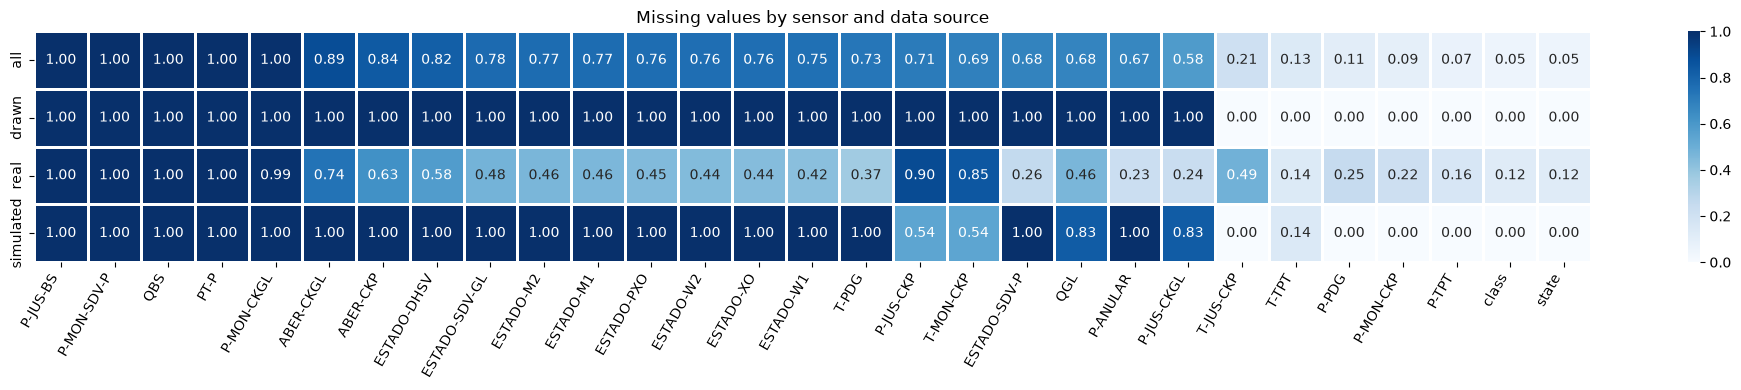

In [5]:
# NaN by sensor and data source
cols = list(df.select_dtypes("float32").columns) + ["class", "state"]
nans = df[cols].isna()

nan_table = pd.concat(
    [nans.mean().rename("all"),
     nans.groupby(df["source"], observed=True).mean().T],
    axis=1,
).sort_values("all", ascending=False).T

# print(nan_table.round(2).to_string())

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(
    nan_table,
    annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
    linewidths=1, linecolor="white",
    ax=ax,
)
ax.set_title("Missing values by sensor and data source")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Five sensors (`P-JUS-BS`, `P-MON-SDV-P`, `QBS`, `PT-P`, `P-MON-CKGL`)  are empty in every row of every source.

The others depend on the source. Simulated instances never record the `ESTADO-*`, `ABER-*`, `T-PDG` and `P-ANULAR` sensors, while real wells record them in at least about half of the rows. The opposite happens with `P-JUS-CKP` and `T-MON-CKP`.
The 20 drawn instances only have `T-JUS-CKP`, `T-TPT`, `P-PDG`, `P-MON-CKP` and `P-TPT`.

The missing values are not random, but depend on the source.

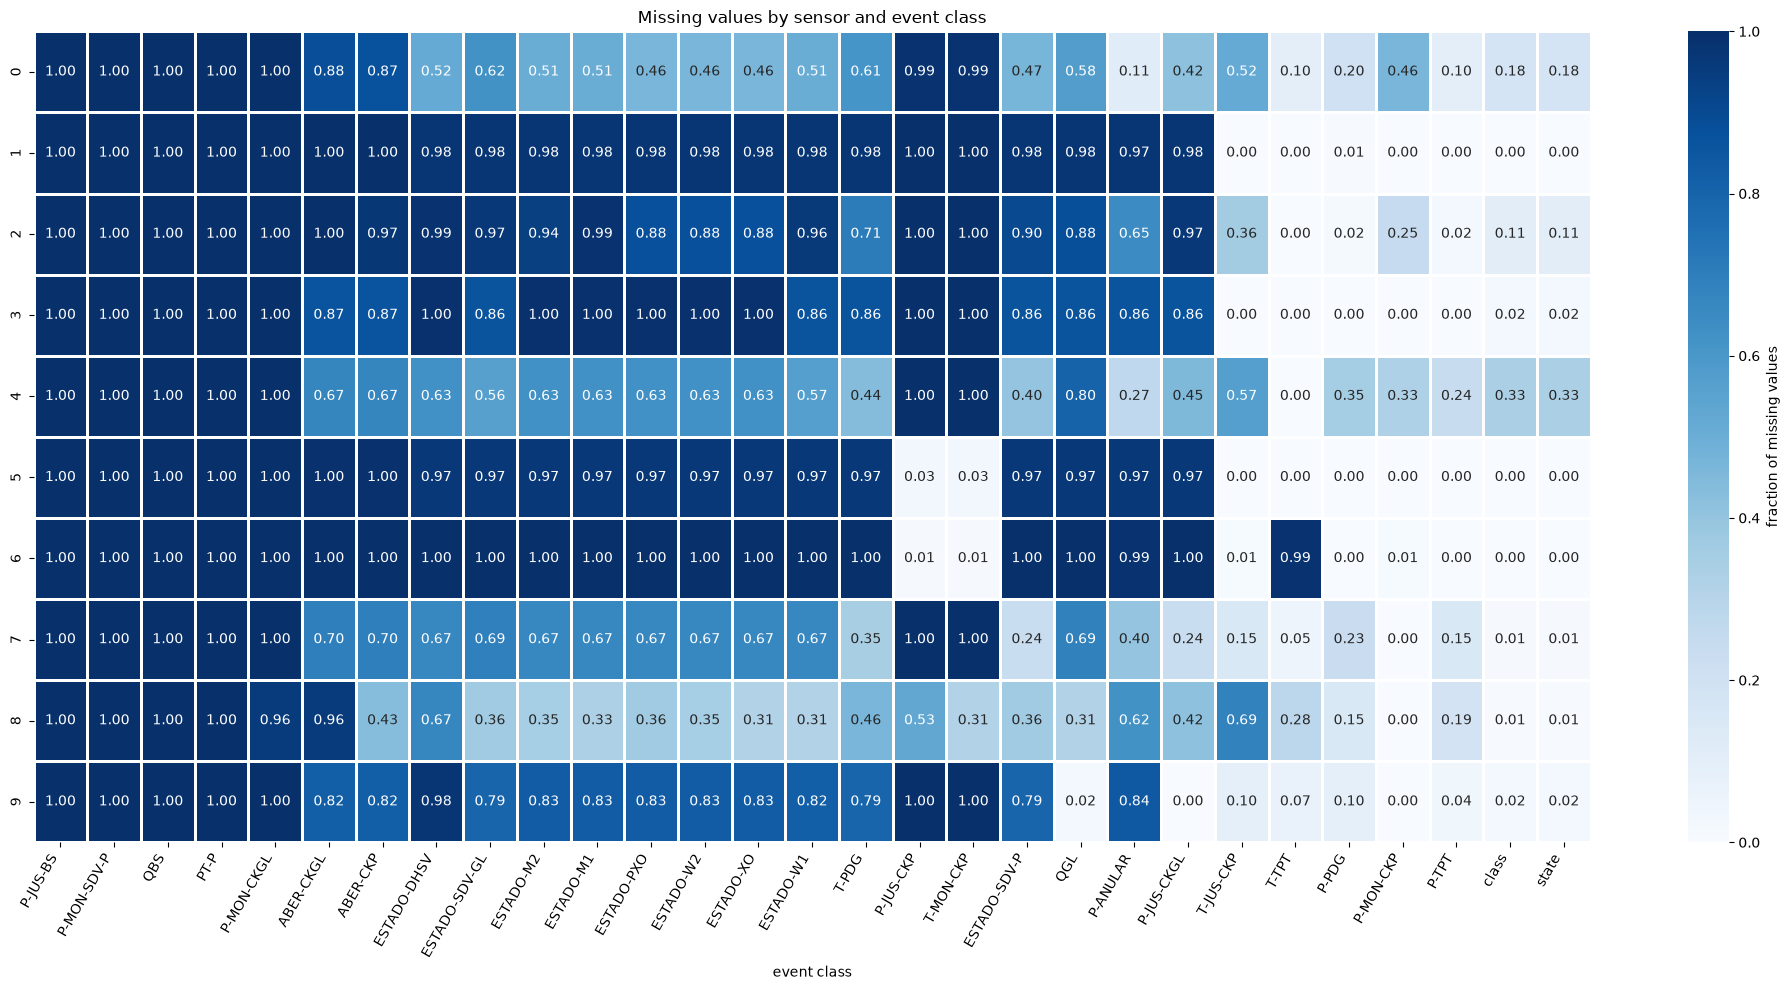

In [6]:
# NaN by sensor and event class
by_class = nans.groupby(df["event_class"]).mean()
by_class = by_class[nan_table.columns]

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    by_class,
    annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
    linewidths=1, linecolor="white",
    cbar_kws={"label": "fraction of missing values"},
    ax=ax,
)
ax.set_title("Missing values by sensor and event class")
ax.set_xlabel("event class")
plt.xticks(rotation=60, ha="right")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Missing values also change with the event class with a clear pattern.
The `ESTADO-*` and `ABER-*` sensors are almost always missing in classes 1, 2, 3, 5 and 6. 
`P-JUS-CKP` and `T-MON-CKP` are present almost only in classes 5 and 6, and empty in most of the others.
`QGL` and `P-JUS-CKGL` are mostly available only in class 9.
`T-TPT` is almost entirely missing in class 6 alone.

In [7]:
# Percentage of instances where a sensor is empty in every row, overall and by source.

# Check whether the sensor missing in every rows of each instance
instance_nan = nans.groupby(df["instance_id"], observed=True).mean()
fully_empty = instance_nan == 1                     # True/False per instance and sensor

# first source of each instance
inst_source = df.groupby("instance_id", observed=True)["source"].first()

# percentage of instances where the sensor is entirely empty (overall and by search)
empty_table = pd.concat(
    [fully_empty.mean().rename("all"),
     fully_empty.groupby(inst_source).mean().T],
    axis=1,
).loc[nan_table.columns]

print(empty_table.round(2).to_string())

                all  drawn  real  simulated
P-JUS-BS       1.00    1.0  1.00       1.00
P-MON-SDV-P    1.00    1.0  1.00       1.00
QBS            1.00    1.0  1.00       1.00
PT-P           1.00    1.0  1.00       1.00
P-MON-CKGL     1.00    1.0  1.00       1.00
ABER-CKGL      0.87    1.0  0.74       1.00
ABER-CKP       0.87    1.0  0.73       1.00
ESTADO-DHSV    0.79    1.0  0.58       1.00
ESTADO-SDV-GL  0.78    1.0  0.57       1.00
ESTADO-M2      0.77    1.0  0.55       1.00
ESTADO-M1      0.78    1.0  0.55       1.00
ESTADO-PXO     0.76    1.0  0.52       1.00
ESTADO-W2      0.76    1.0  0.52       1.00
ESTADO-XO      0.76    1.0  0.52       1.00
ESTADO-W1      0.75    1.0  0.50       1.00
T-PDG          0.75    1.0  0.50       1.00
P-JUS-CKP      0.70    1.0  0.99       0.40
T-MON-CKP      0.70    1.0  0.99       0.40
ESTADO-SDV-P   0.70    1.0  0.41       1.00
QGL            0.73    1.0  0.60       0.86
P-ANULAR       0.59    1.0  0.18       1.00
P-JUS-CKGL     0.62    1.0  0.38

This table counts instances instead of rows. A value of 1.00 means the sensor is absent from every instance of that source. 

The percentage of instances in real wells without a sensor is almost the same as the share of empty rows in the previous heatmap, which means the sensor is either recorded for the whole instance or not at all.

Only five sensors are available in every source: `T-JUS-CKP`, `T-TPT`, `P-PDG`, `P-MON-CKP` and `P-TPT`, which makes them the safest candidates for a feature set shared by all sources.

In [8]:
# Rows without a label
unlabeled = df["class"].isna()
print(f"Unlabeled rows: {unlabeled.sum():,} ({unlabeled.mean():.2%})")
print("class and state missing together:", (unlabeled == df["state"].isna()).mean())

print("\nFraction unlabeled by source:")
print(unlabeled.groupby(df["source"], observed=True).mean().round(4))

# Position of each row inside its instance (0 = first row)
pos = df.groupby("instance_id", observed=True).cumcount()

# Check if unlabeled rows are only at the beginning of the instance
n_unlabeled = unlabeled.groupby(df["instance_id"], observed=True).sum()
first_labeled = pos.where(~unlabeled).groupby(df["instance_id"], observed=True).min()

has_unl = n_unlabeled > 0
print(f"\nInstances with unlabeled rows: {has_unl.sum()} of {len(n_unlabeled)}")
print("Instances with unlabeled rows only at the start:",
      (n_unlabeled[has_unl] == first_labeled[has_unl]).sum())
print("\nUnlabeled rows per instance:")
print(n_unlabeled[has_unl].describe())


Unlabeled rows: 4,028,400 (5.26%)
class and state missing together: 1.0

Fraction unlabeled by source:
source
drawn        0.0000
real         0.1225
simulated    0.0000
Name: class, dtype: float64

Instances with unlabeled rows: 1119 of 2228
Instances with unlabeled rows only at the start: 1119

Unlabeled rows per instance:
count    1119.0
mean     3600.0
std         0.0
min      3600.0
25%      3600.0
50%      3600.0
75%      3600.0
max      3600.0
Name: class, dtype: float64


There are 4M rows without a label (5.26% of the dataset), and `class` and `state` are always missing together. Simulated and drawn classes are fully labeled.

All 1,119 real instances have unlabeled rows, always at the beginning and always exactly 3,600 of them (the standard deviation is zero), which looks like one hour of data at one reading per second. 

These rows have no target, so they cannot be used for supervised training or evaluation. This is systematic, so the simple fix is to cut the first 3,600 rows of each real instance. 

In [9]:
# Shape of the missing values inside an instance (random sample)
sensors = df.select_dtypes("float32").columns
rng = np.random.default_rng(42)

sample_ids = rng.choice(fully_empty.index, size=1000, replace=False)
sample = df[df["instance_id"].isin(sample_ids)]

def nan_pattern(isn):
    """Classify the missing values of one sensor in an instance."""
    if not isn.any():
        return "complete"
    if isn.all():
        return "empty"

    valid = np.flatnonzero(~isn) # return indexes of valid values
    first = valid[0] 
    last = valid[-1]

    if isn[first:last + 1].any():
        return "internal gaps"
    if first > 0 and last < len(isn) - 1:
        return "leading + trailing"
    
    return "leading only" if first > 0 else "trailing only"

rows = []
for iid, g in sample.groupby("instance_id", observed=True):
    for s in sensors:
        rows.append((s, nan_pattern(g[s].isna().to_numpy())))

patterns = pd.crosstab(pd.Series([r[0] for r in rows], name="sensor"),
                       pd.Series([r[1] for r in rows], name="pattern"))
print(patterns.loc[nan_table.columns.intersection(patterns.index)].to_string())


pattern        complete  empty  internal gaps  leading + trailing  trailing only
P-JUS-BS              0   1000              0                   0              0
P-MON-SDV-P           0   1000              0                   0              0
QBS                   0   1000              0                   0              0
PT-P                  0   1000              0                   0              0
P-MON-CKGL            1    999              0                   0              0
ABER-CKGL           108    888              4                   0              0
ABER-CKP            111    885              4                   0              0
ESTADO-DHSV         200    797              3                   0              0
ESTADO-SDV-GL       202    787             11                   0              0
ESTADO-M2           210    786              4                   0              0
ESTADO-M1           210    786              4                   0              0
ESTADO-PXO          223    7

I classified 1000 random instances as complete, completely empty, or with gaps in order to see how the missing values are arranged in time.

Most of the cases are either complete or completely empty. 

At most 20 instances out of 1,000 for a sensor have gaps inside. Leading or trailing missing values appear only for `T-PDG` and `P-PDG` in 1/2 instances.

So the missing values are structural, a sensor is either recorded for the whole instance or not recorded at all. This means that there is almost nothing to interpolate in time.

## 2.2 Class distribution

In this part I look at how the records are distributed across the event classes. 

Just as a reminder, `class` has three kind of values:
- *0* for normal operation
- *1-9* for the fault classes
- *101-109* for transient period that precedes the stable fault 

Counting rows instead of instances is important because the instances have very different lengths, we don't wanna give more weight to longer instances.

The counts show how unbalanced the classes are, which is useful for choice of metrics and split strategy.

           rows  percentage       type
class                                 
0      17305269    0.238500     normal
1       2909887    0.040104      fault
2        366858    0.005056      fault
3       4834079    0.066623      fault
4       2454883    0.033833      fault
5      10553279    0.145444      fault
6       3879083    0.053461      fault
7        138148    0.001904      fault
8        744061    0.010255      fault
9       3203605    0.044152      fault
101     5265821    0.072573  transient
102      146691    0.002022  transient
105     2423367    0.033399  transient
106     1558565    0.021480  transient
107     8714480    0.120102  transient
108     5093397    0.070197  transient
109     2967445    0.040897  transient


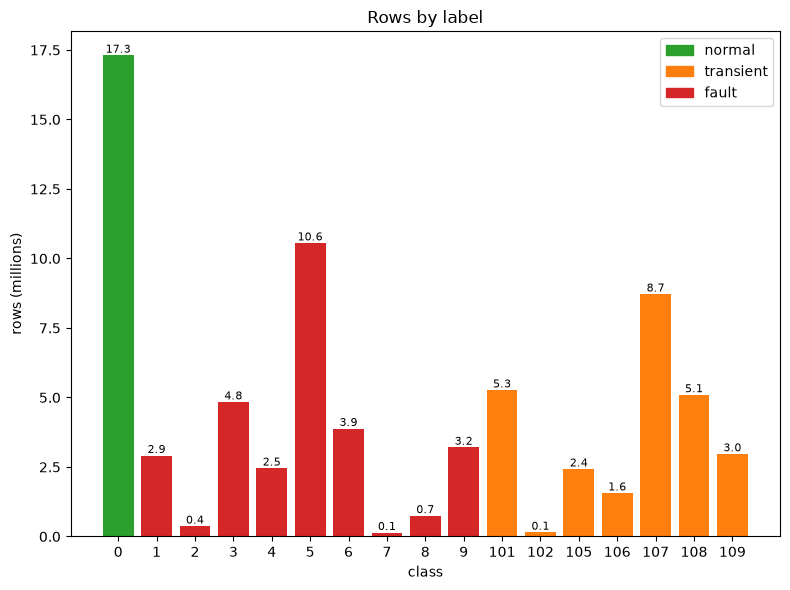

In [10]:
# Labeled rows by class
labeled = df["class"].dropna().astype(int)

def label_type(c):
    return "normal" if c == 0 else "transient" if c > 100 else "fault"

row_counts = labeled.value_counts().sort_index().to_frame("rows")
row_counts["percentage"] = row_counts["rows"] / row_counts["rows"].sum()
row_counts["type"] = [label_type(c) for c in row_counts.index]
print(row_counts)


# Graph
colors = {"normal": "tab:green", "transient": "tab:orange", "fault": "tab:red"}

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(row_counts.index.astype(str), row_counts["rows"] / 1e6,
       color=[colors[t] for t in row_counts["type"]])
ax.set_xlabel("class")
ax.set_ylabel("rows (millions)")
ax.set_title("Rows by label")
ax.bar_label(ax.containers[0], fmt="%.1f", fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys())
plt.tight_layout()
plt.show()

in total 23.9% are normal, 40.1% are stable fault and 36.1% are transient.

Since the classes are this unbalanced, accuracy would not be an ideal metric, and a macro-averaged score like F1 macro whould be a better choice.

In [11]:
# Rows by fault class and source
faults = df[df["class"].between(1, 9)]
fault_rows = (faults.groupby(["class", "source"], observed=True).size()
                    .unstack(fill_value=0))
fault_rows["real_percentage"] = fault_rows["real"] / fault_rows.sum(axis=1)
print(fault_rows)

source   drawn     real  simulated  real_percentage
class                                              
1        27391     9783    2872713         0.003362
2            0    21274     345584         0.057990
3            0   569152    4264927         0.117737
4            0  2454883          0         1.000000
5            0    13205   10540074         0.001251
6            0    13285    3865798         0.003425
7       107809    30339          0         0.219612
8            0   140920     603141         0.189393
9            0    17752    3185853         0.005541


Classes 1, 5, 6 and 9 have less than 1% of real rows. 

Class 4 is all real and provides 75% of all the real fault rows, so a test set made of real wells only would be dominated by this class and the scores of other classes would be based on very little data.

Class 7 has 22% real rows and the rest is hand-drawn.

A model could learn to recognize the source instead of the fault. Best to avoid the sensors present only in real wells.

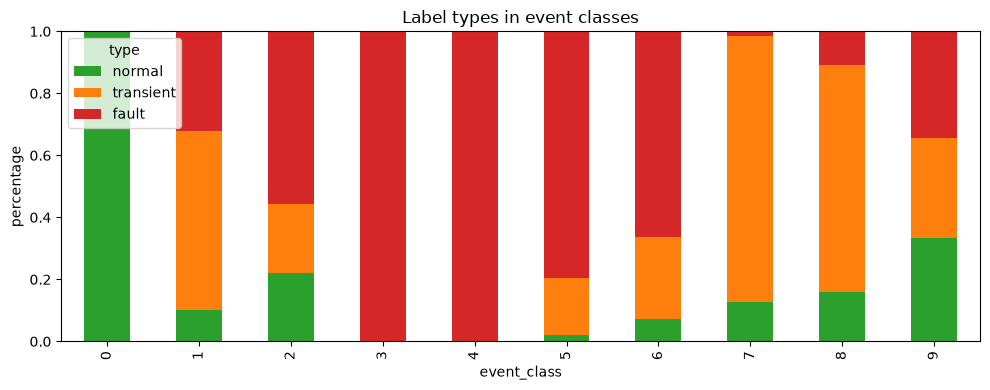

In [12]:
# Labeled rows split for each event class
by_event = (df.dropna(subset=["class"])
              .assign(type=lambda d: d["class"].astype(int).map(label_type))
              .groupby(["event_class", "type"], observed=True).size()
              .unstack(fill_value=0))
by_event = by_event.div(by_event.sum(axis=1), axis=0)[["normal", "transient", "fault"]]

by_event.plot.bar(stacked=True, figsize=(10, 4), color=list(colors.values()))
plt.ylabel("percentage")
plt.title("Label types in event classes")
plt.tight_layout()
plt.show()


The percentage of each label type changes a lot between the event classes. 

- class 0 is entirely normal.
- classes 3 and 4 are entirely stable fault.
- classes 5 and 6 are mostly stable fault.
- classes 1, 7 and 8 the transient is the largest part. 

Class 7 is pretty much all transient, while class 9 is the most balanced one.

How to treat the transients differ from each class. If the transient is excluded, classes 1, 7 and 8 would lose most of their rows.

## 2.3 Sensor time-series

In this part I'll show how the sensors behave over time in each event class.

For every class I'll choose only one real instance, the one with a length closest to the median length of the real instances of that class. I will not consider the 3,600 unlabeled rows at the beginning, and instances that does not contain a fault or a transient. 

After choosing the instances I will plot the time-series for the 5 sensors that are available in each source (`T-JUS-CKP`, `T-TPT`, `P-PDG`, `P-MON-CKP` and `P-TPT`).

The goal is to see whether the fault is visible in the signal, and how different the classes are from each other.

In [55]:
# one real instance per event class, closest to the median length,
# only consider instances that contain a fault or a transient
df_grp = df.groupby("instance_id", observed=True)

inst_info = pd.DataFrame({
    "length": df_grp.size(),
    "source": df_grp["source"].first(),
    "event_class": df_grp["event_class"].first(),
    "has_event": (df["class"].fillna(0) != 0).groupby(df["instance_id"], observed=True).any(),
})
inst_info = inst_info[inst_info["source"] == "real"]
candidates = inst_info[(inst_info["event_class"] == 0) | inst_info["has_event"]]

chosen = {}
for c, g in candidates.groupby("event_class"):
    median_len = g["length"].median()
    chosen[c] = (g["length"] - median_len).abs().idxmin()

chosen_df = inst_info.loc[list(chosen.values())].sort_values("event_class")
print(chosen_df)

                             length source  event_class  has_event
instance_id                                                       
0/WELL-00001_20170201010207   21474   real            0      False
1/WELL-00001_20140124083303   62068   real            1       True
2/WELL-00012_20170320011000   10539   real            2       True
3/WELL-00014_20170918010114   21527   real            3       True
4/WELL-00001_20170318130000   10759   real            4       True
5/WELL-00020_20140319021600   31441   real            5       True
6/WELL-00002_20140301141700   15078   real            6       True
7/WELL-00024_20160704180000  154801   real            7       True
8/WELL-00019_20141117190526  314604   real            8       True
9/WELL-00037_20181011071238   31643   real            9       True


In [56]:
# row count for the 10 instances
subset = df[df["instance_id"].isin(chosen.values())]

examples = {}
for c, iid in chosen.items():
    d = subset[subset["instance_id"] == iid]
    d = d.dropna(subset=["class"]).reset_index(drop=True)
    d["hours"] = np.arange(len(d)) / 3600
    d["label_type"] = d["class"].astype(int).map(label_type)
    examples[c] = d

for c, d in examples.items():
    print(f"class {c} rows: {len(d)}")

class 0 rows: 17874
class 1 rows: 58468
class 2 rows: 6939
class 3 rows: 17927
class 4 rows: 7159
class 5 rows: 27841
class 6 rows: 11478
class 7 rows: 151201
class 8 rows: 311004
class 9 rows: 28043


These values are how many rows there are in the 10 chosen instances, each row is a second. 

The shortest one (class 2) is only less than 2 hours long, while the longest (class 8) is more than 86 hours.

In [57]:
LABEL_COLORS = {"normal": "tab:green", "transient": "tab:orange", "fault": "tab:red"}

def plot_sensor(sensor, step=10):
    """One panel per event class, sensor line over a background coloured by label type."""
    fig, axes = plt.subplots(5, 2, figsize=(16, 14), sharex=False)
    for ax, c in zip(axes.ravel(), sorted(examples)):
        d = examples[c]
        if d[sensor].isna().all():
            ax.text(0.5, 0.5, "sensor not recorded", ha="center", va="center",
                    transform=ax.transAxes)
        else:
            for t, color in LABEL_COLORS.items():
                ax.fill_between(d["hours"], 0, 1, where=(d["label_type"] == t),
                                color=color, alpha=0.2, linewidth=0,
                                transform=ax.get_xaxis_transform())
            ax.plot(d["hours"][::step], d[sensor][::step], color="black", lw=0.8)
        ax.set_title(f"class {c} ({chosen[c].split('/')[1][:20]})", fontsize=9)
        ax.set_xlabel("hours")
    handles = [plt.Rectangle((0, 0), 1, 1, color=col, alpha=0.3)
               for col in LABEL_COLORS.values()]
    fig.legend(handles, LABEL_COLORS.keys(), loc="upper right")
    fig.suptitle(f"{sensor}: one real instance per event class", fontsize=14)
    plt.tight_layout()
    plt.show()

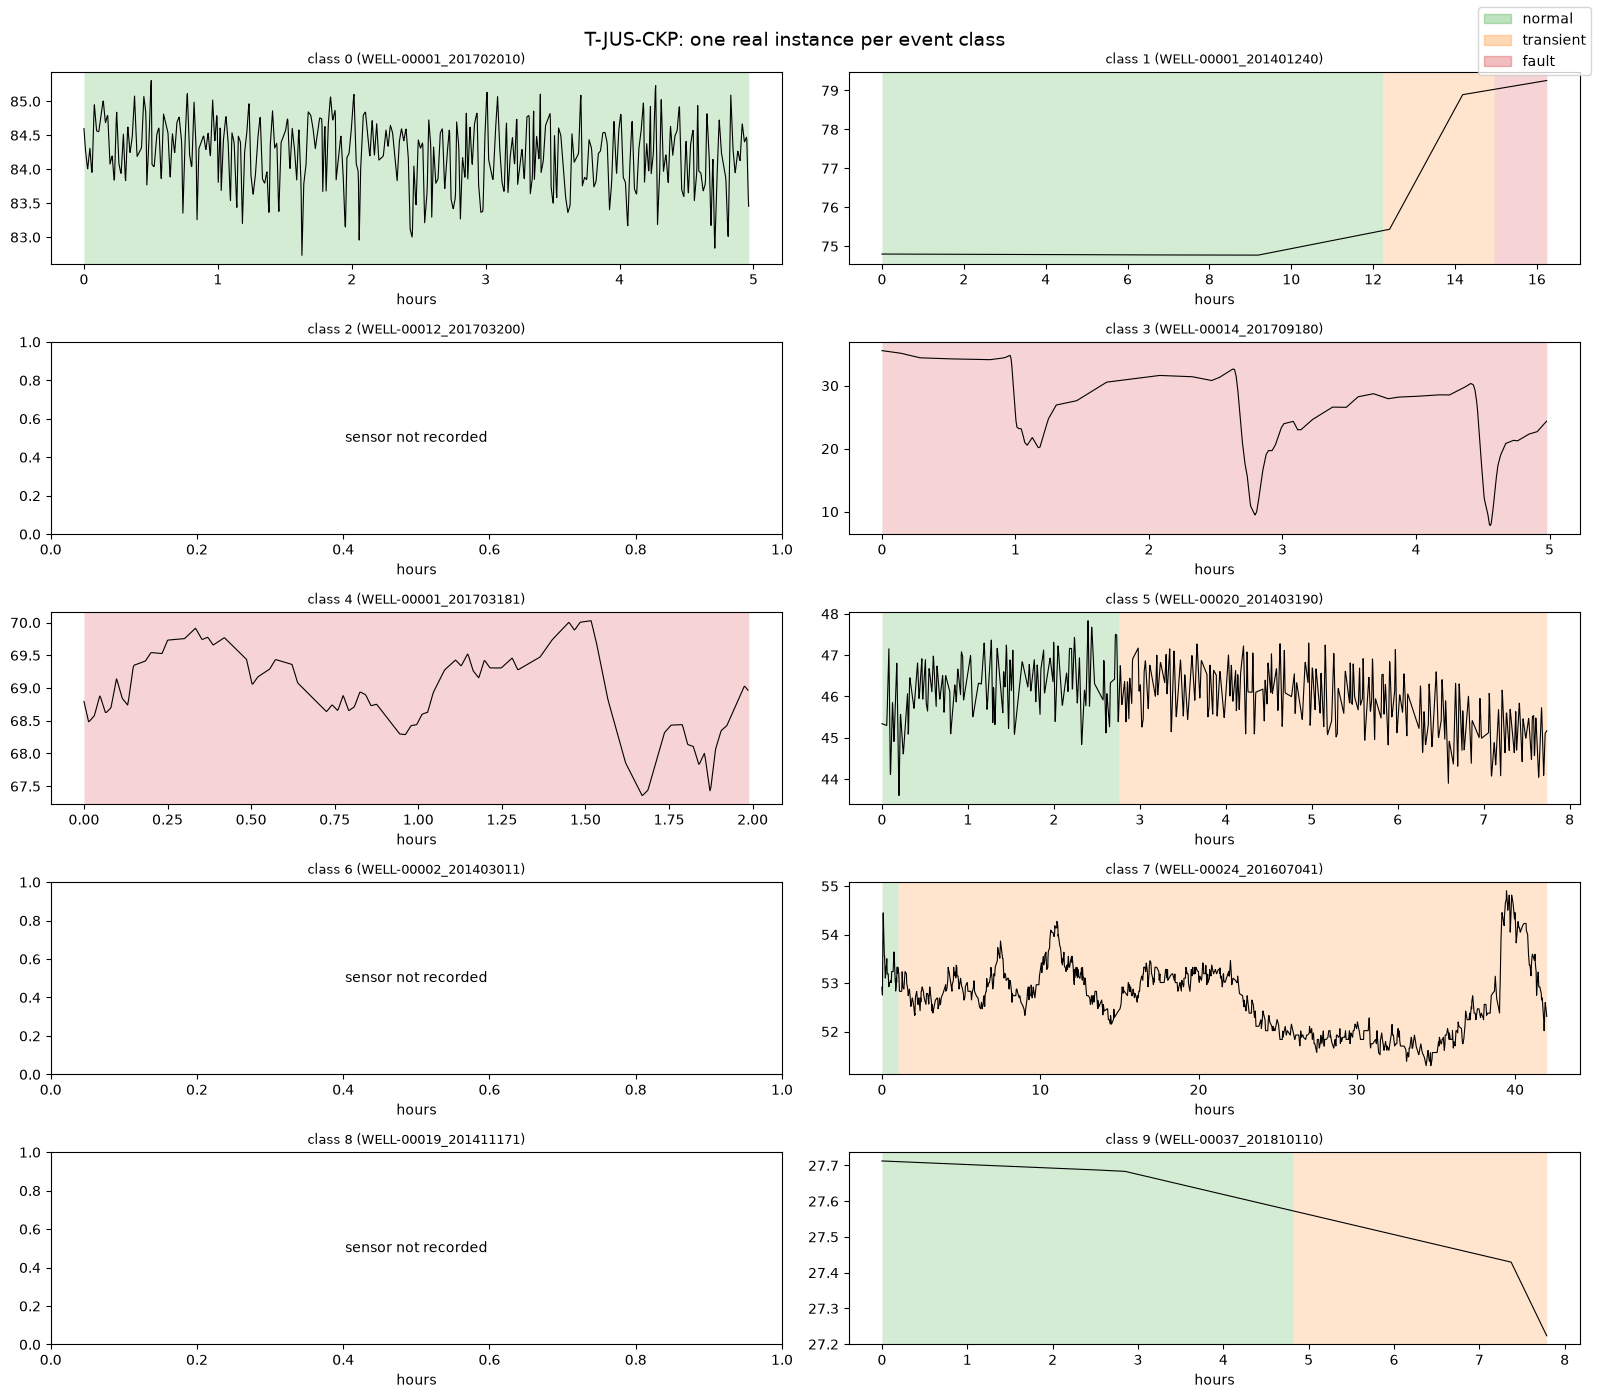

In [58]:
plot_sensor("T-JUS-CKP")

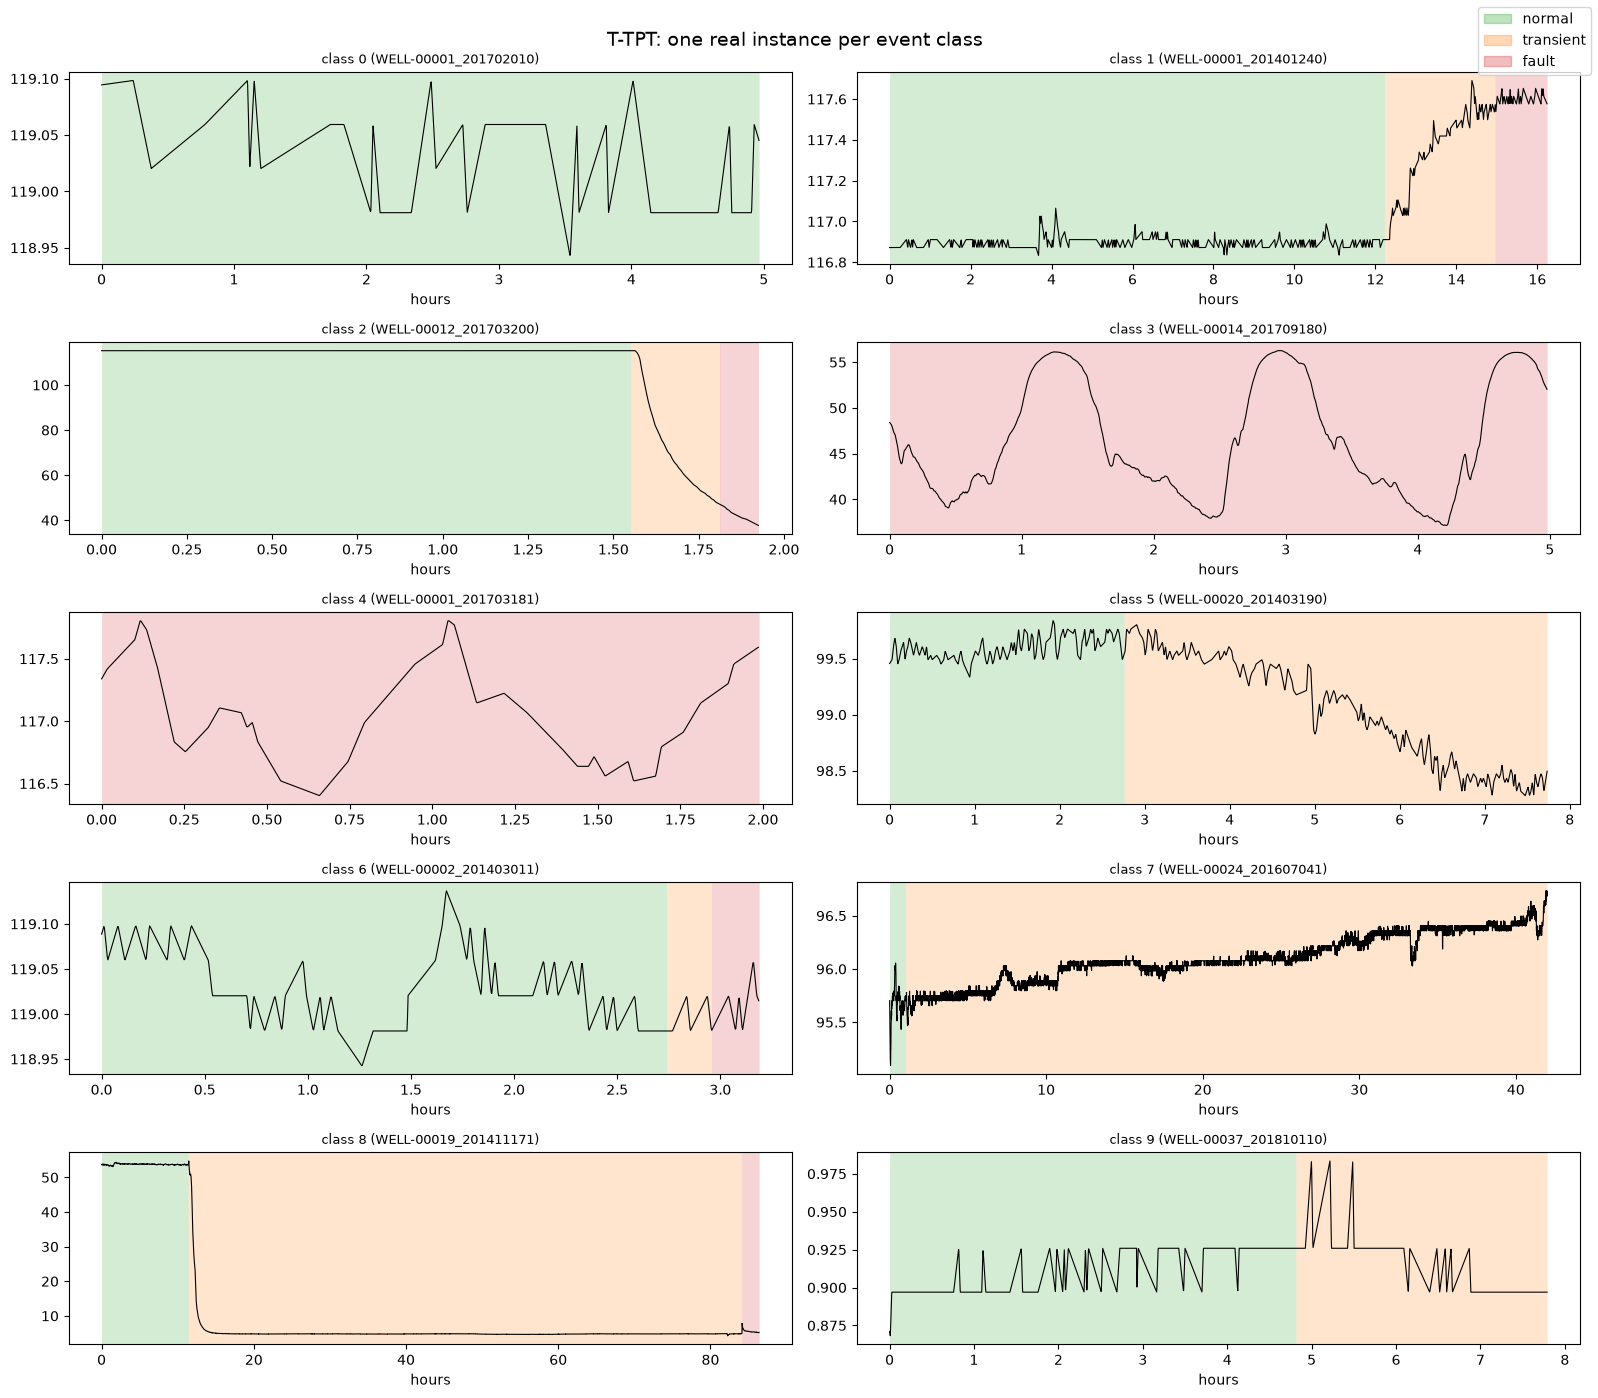

In [59]:
plot_sensor("T-TPT")

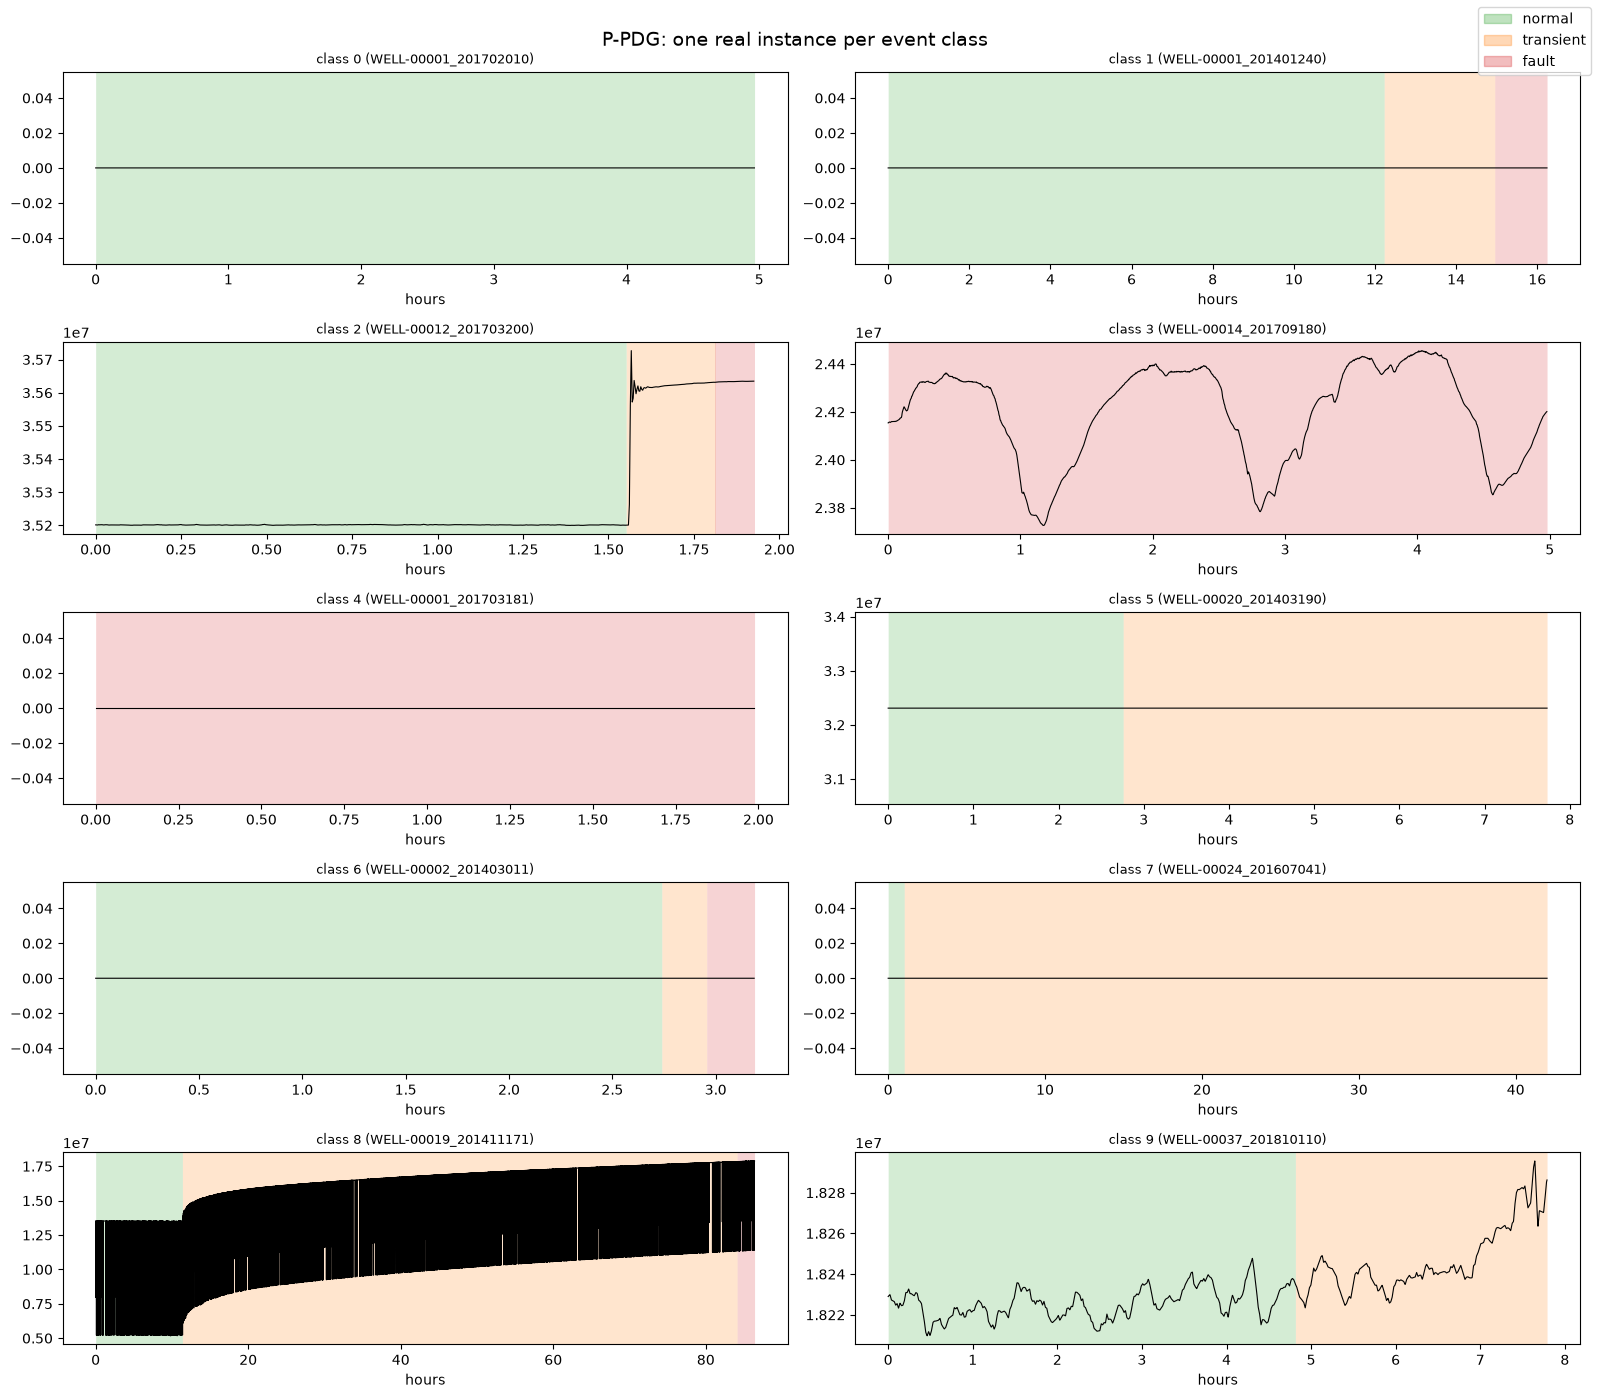

In [60]:
plot_sensor("P-PDG")

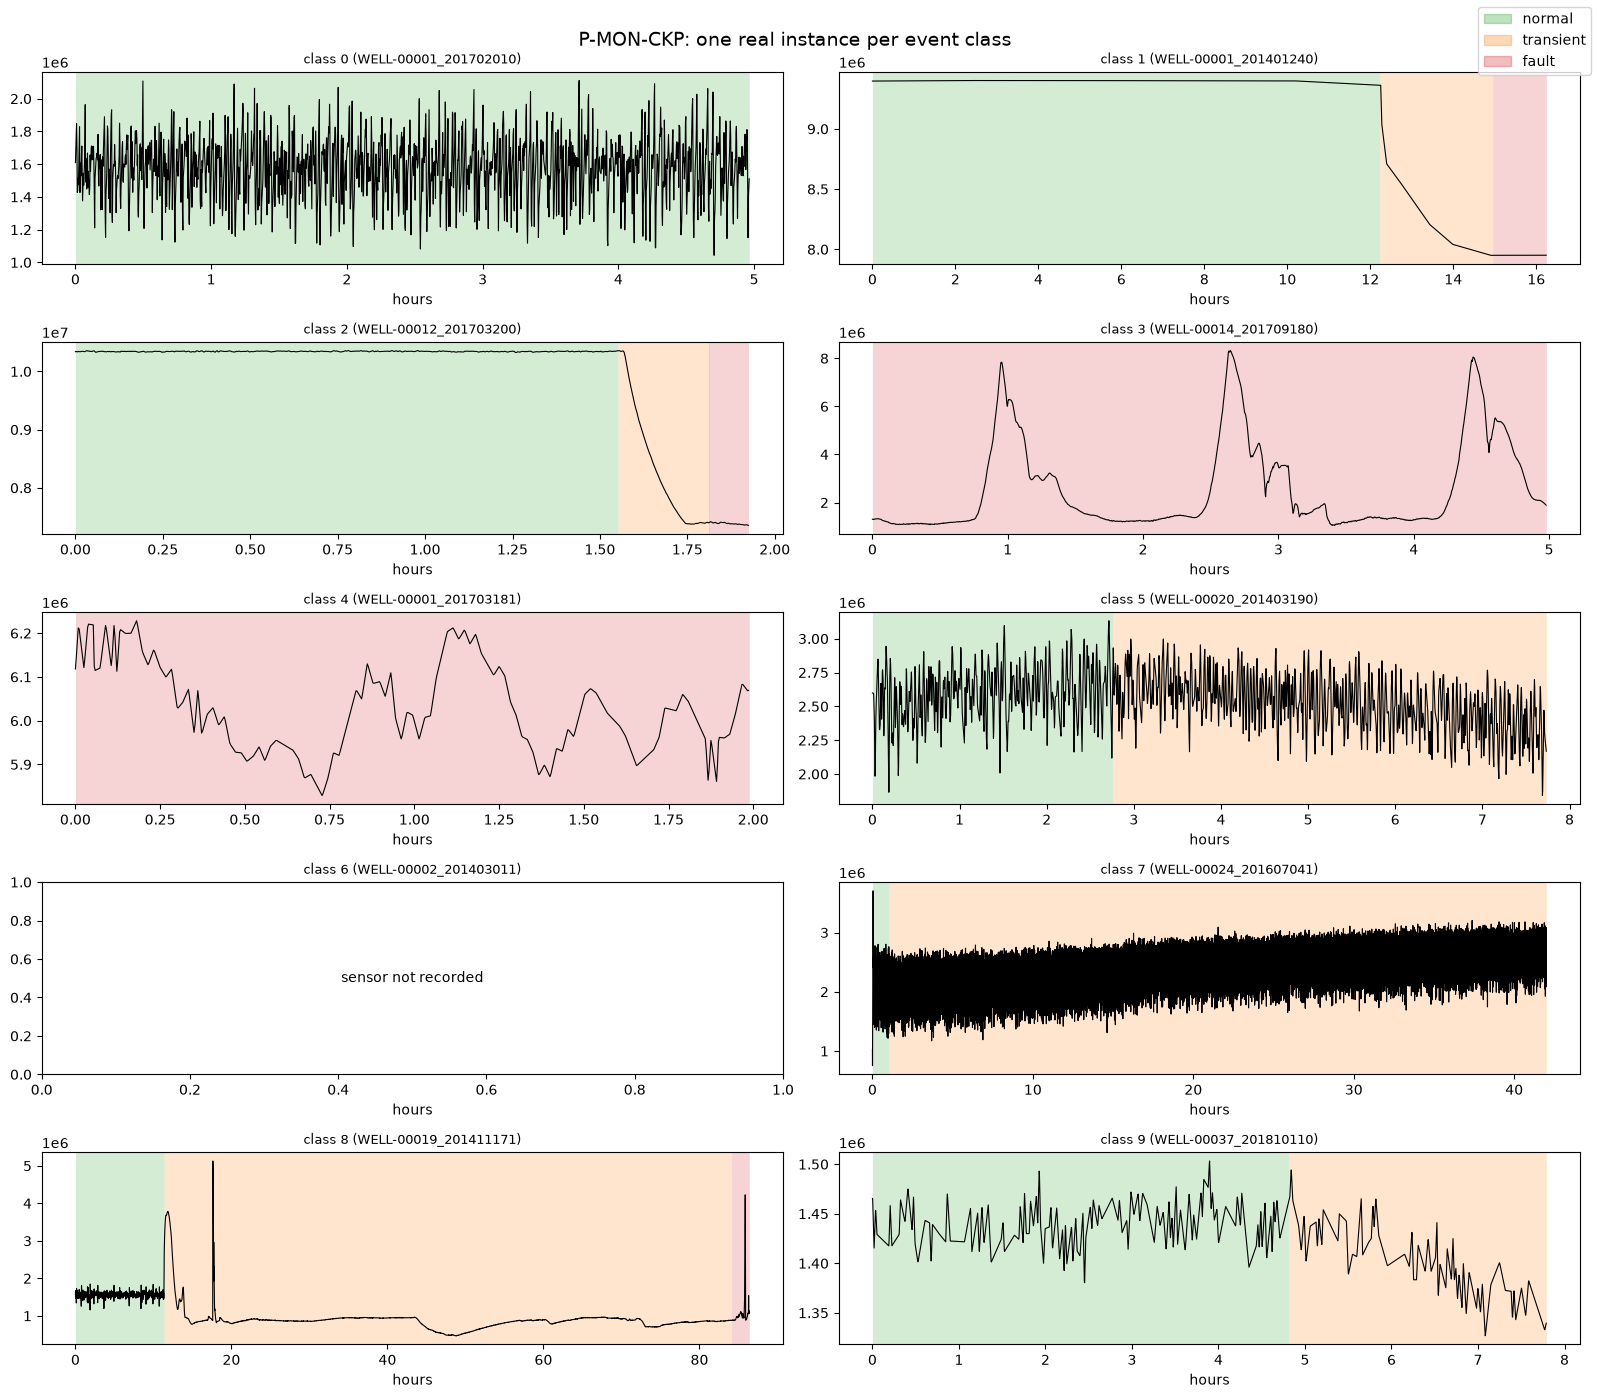

In [61]:
plot_sensor("P-MON-CKP")

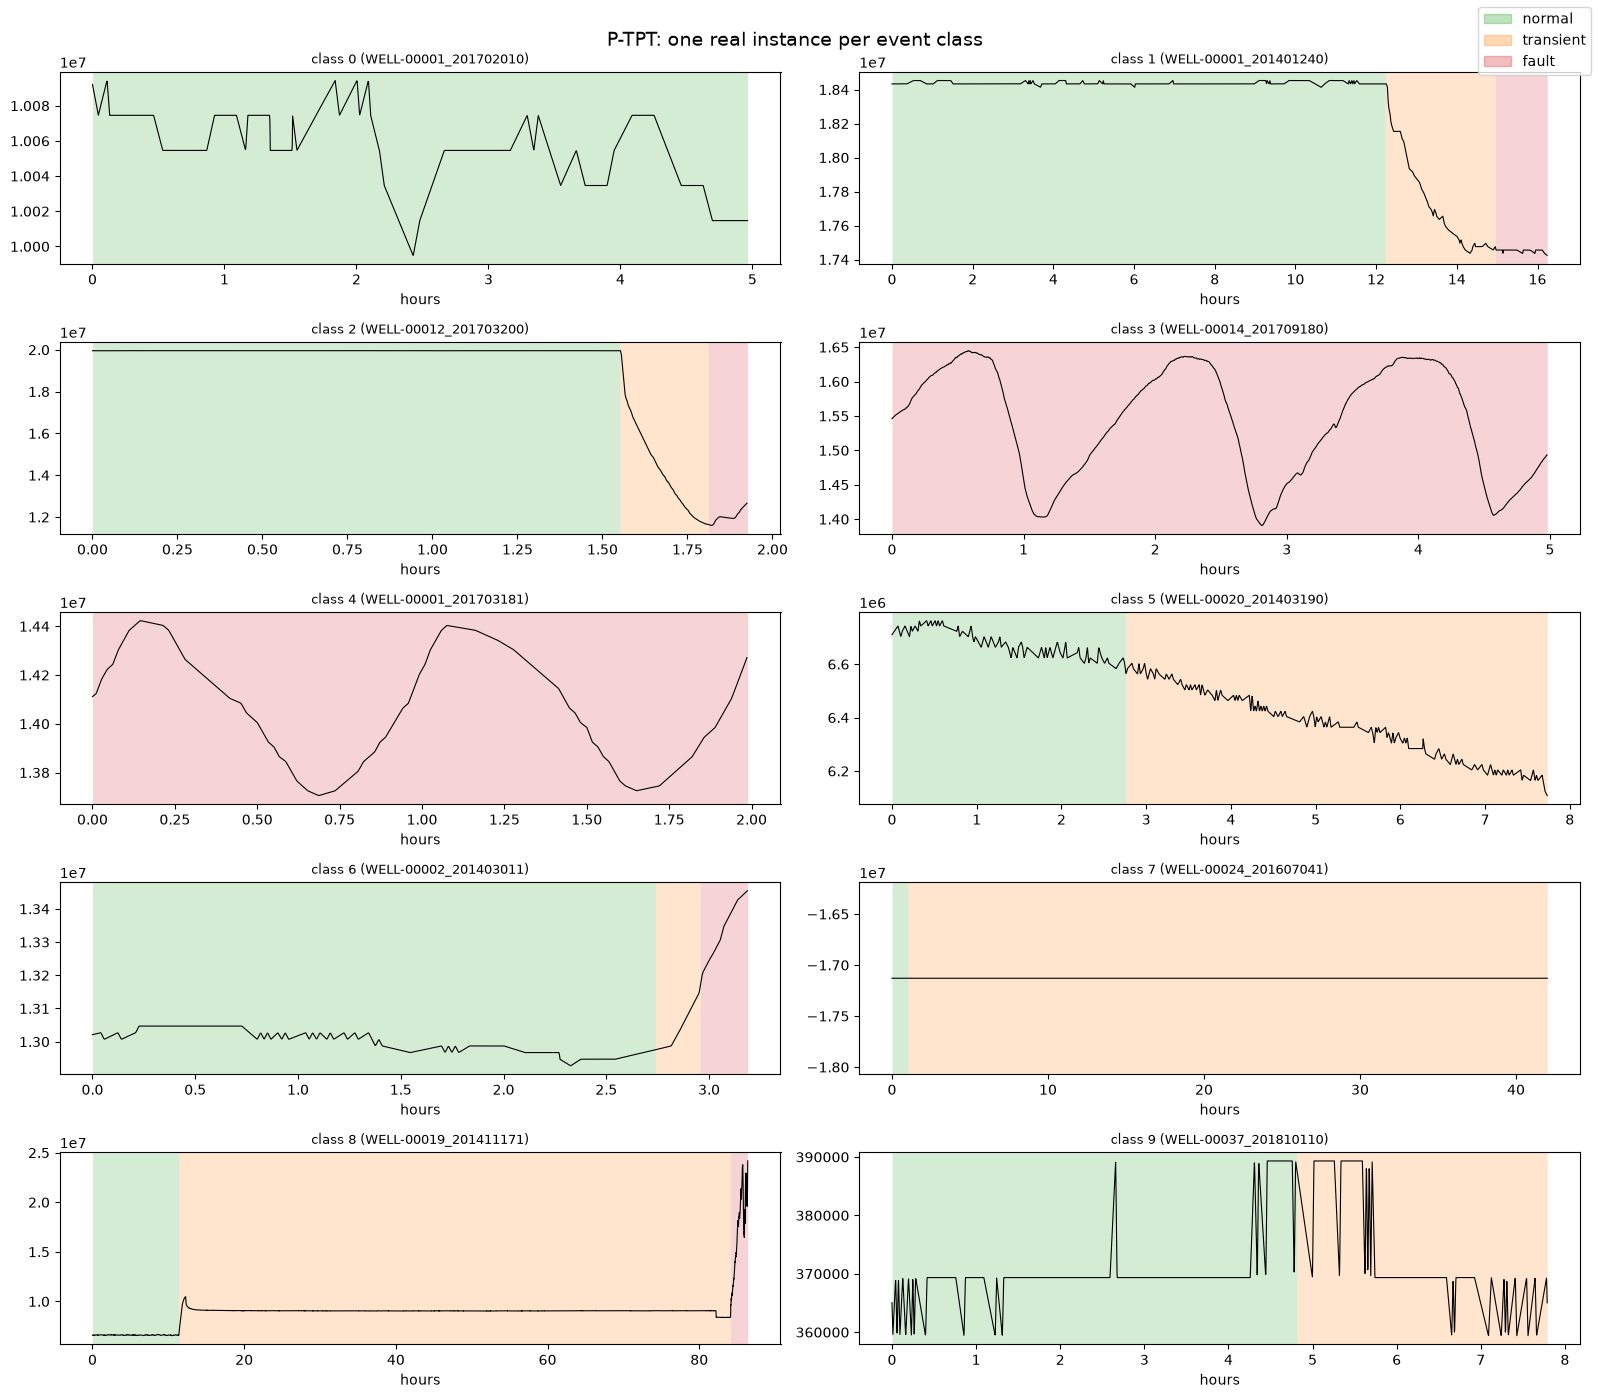

In [62]:
plot_sensor("P-TPT")

Each figure show the time-serie for one sensor, and have one panel for each event class.

The black line is the sensor value over time (one point every 10 seconds), and the background color is the label (normal is green, orange is transient, and red is stable fault).

I just plotted one median instance for each class, not the average behaviour of the class. Y-axis is different for each panel.

The fault is visible in the signal for some classes:
- In classes 1, 2 and 8 the sensors change right at the start of the transient. In class 5 the drift begins before the transient, so the label border is not always visible in the signal.
- Classes 3 and 4 are entirely stable fault, and the signals oscillate periodically, visible in more than one sensor.
- Class 0 seems stable but has some noise in `P-MON-CKP` and `T-JUS-CKP`.


`P-PDG` is constant at 0 in classes 0, 1, 4, 6 and 7, which looks like a sensor that is not working.
`P-TPT` in class 7 is negative and constant, which is not physically possible.

## 2.4 Correlation heatmap

## 2.5 Boxplot and outliers

## 2.?

In [51]:
# Length of instances
df.groupby("instance_id", observed=True).size().describe()

count      2228.000000
mean      34374.918312
std       50238.524841
min        5215.000000
25%       21342.750000
50%       26999.000000
75%       29299.000000
max      768314.000000
dtype: float64